In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from typing import Optional, Tuple

import time

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [2]:
from datetime import datetime
def showTime():
    return str("["+datetime.now().strftime('%Y-%m-%d %H:%M:%S.%f')+" UTC]")

In [3]:
class Head(nn.Module):
    """A single self-attention head for a Transformer model with causal masking.

    This module processes input embeddings into query, key, and value vectors,
    computes scaled dot-product attention scores with causal masking to prevent 
    future context leakage, and outputs weighted value vectors.

    Attributes:
        key (nn.Linear): Projects input embeddings to key vectors of shape (head_size).
        query (nn.Linear): Projects input embeddings to query vectors of shape (head_size).
        value (nn.Linear): Projects input embeddings to value vectors of shape (head_size).
        tril (Tensor): Lower triangular mask buffer enforced during attention computation.
        dropout (nn.Dropout): Dropout layer applied post-softmax for regularization.
    """

    def __init__(self, n_embd: int, head_size: int, block_size: int, dropout: float) -> None:
        """Initialize the self-attention head.
        
        Args:
            n_embd (int): Input embedding dimension (must match input's last dimension).
            head_size (int): Dimensionality of key/query/value vectors (output size).
            block_size (int): Maximum sequence length for the causal mask buffer.
            dropout (float): Dropout probability for attention weights (0-1 range).
        """
        super().__init__()

        # [KEY, QUERY, VALUE LINEAR PROJECTIONS]
        # Linear layers project embeddings to lower-dimensional key/query/value spaces 
        # without bias terms (common in some Transformer architectures for simplicity)
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        # [CAUSAL MASK CREATION]
        # Creates a fixed triangular mask for enforcing sequential order dependencies
        # Lower triangular part (1s below and on the main diagonal) allows attention 
        # to current and previous positions only. Stored as a buffer, not a learnable parameter
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        # [DROPOUT LAYER]
        # Reduces overfitting by randomly zeroing attention probabilities during training
        self.dropout = nn.Dropout(dropout)


    # x Tensor shape (batch_size, time_steps, embedding_dim)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Perform self-attention computation on input tensor.
        
        Args:
            x (Tensor): Input embeddings tensor
            
        Returns:
            Tensor: Output attention vectors of shape (B, T, head_size)
        """
        # --- DIMENSION UNPACKING ---
        # B=batch_size, T=sequence_length, C=embedding_dim
        B,T,C = x.shape

        # --- LINEAR PROJECTIONS ---
        # Project embeddings into query, key, and value spaces (all T x head_size matrices)
        k = self.key(x)    # (B, T, head_size) - projected key vectors
        q = self.query(x)  # (B, T, head_size) - projected query vectors


        # --- ATTENTION SCORE COMPUTATION ---
        # 1. Compute query-key dot product for all pairs (scaled to prevent softmax saturation)
        wei = q @ k.transpose(-2,-1) # (B, T, head_size) @ (B, head_size, T) => (B, T, T)
        scale_factor = (k.shape[-1])**-0.5 # sqrt(head_size) for stability
        wei_scaled = wei / scale_factor     # Scaling prevents extreme values

        # 2. Apply causal mask to enforce sequential order
        # Masking ensures position i can't attend to j > i (future tokens)
        # Crop mask to current sequence length T
        wei_scaled = wei_scaled.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # mark upper triangle (forbidden)

        # 3. Softmax normalization to get probabilities
        # Large negative values (-inf) become zero after softmax
        att_weights = F.softmax(wei_scaled, dim=-1)  # (B, T, T)

        # 4. Apply dropout to attention probabilities
        # Dropout randomly nullifies connections for regularization
        att_weights_dropped = self.dropout(att_weights)
        
        # --- VALUE COMBINING ---
        # Project input to value vectors then combine using attention weights
        v = self.value(x)         # (B, T, head_size) - projected value vectors
        # Matrix multiplication (B, T, T) x (B, T, head_size) = (B, T, head_size)
        out = att_weights_dropped @ v  

        return out


class MultiHeadAttention(nn.Module):
    """MultiHeadAttention implements parallel self-attention for multiple heads to process inputs independently.

    This module combines the outputs of multiple attention heads (via concatenation) and applies 
    a linear projection to restore the original embedding dimensionality. It is designed for 
    sequential/casual attention (e.g., in language modeling) where each position attends only to previous tokens.

    Parameters:
        n_embd (int): Input embedding dimension (must match the last dimension of the input tensor).
        num_heads (int): Number of parallel self-attention heads.
        head_size (int): Dimensionality of key, query, and value vectors for each head.
        block_size (int): Maximum context length for positional masking (shared with all heads). 
        dropout (float): Dropout probability applied to attention weights (head levels) and output (post-projection).

    Attributes:
        heads (nn.ModuleList): List of self-attention heads responsible for parallel computations.
        proj (nn.Linear): Projects the concatenated head outputs back to the original embedding dimension.
        dropout (nn.Dropout): Regularization layer applied after the projection.
    """

    def __init__(self, n_embd: int, num_heads: int, head_size: int, block_size: int, dropout: float) -> None:
        """Initialize the multi-head attention module with parallel heads and projection layer.
        
        Args:
            n_embd (int): Input embedding dimension (input's last dimension).
            num_heads (int): Number of parallel attention heads.
            head_size (int): Dimension of each head's key/query/value vectors.
            block_size (int): Max context length for causal masking (used by each head).
            dropout (float): Dropout rate for attention weights and output (0-1 range).
        """
        super().__init__()
        # 1. Create parallel heads
        # Each head is initialized with identical parameters and structure
        self.heads = nn.ModuleList([Head(n_embd, head_size, block_size, dropout) for _ in range(num_heads)])

        # 2. Concatenation projection layer
        # Combines outputs from all heads into original embedding dimension
        # Total input dimension = head_size * num_heads (sum of all heads' outputs)
        # Output dimension = n_embd
        self.proj = nn.Linear(head_size * num_heads, n_embd)

        # 3. Dropout for regularization after projection
        self.dropout = nn.Dropout(dropout)
        
    # x input with shape (batch_size, seq_length, embedding_dim)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Process input through parallel heads and project output.
        
        Args:
            x (Tensor): Input embeddings tensor
            
        Returns:
            Tensor: Processed embeddings tensor (batch_size, seq_length, embedding_dim)
        """
        # Step 1: Compute attention outputs for each head in parallel
        # - Each head processes input tensor independently → outputs (B, T, head_size)
        # - Cropping example: For 3 heads → list [head1_output, head2_output, head3_output]
        # - Final concatenated shape before projection: (B, T, head_size * num_heads)
        outputs = [h(x) for h in self.heads]  # type: list[Tensor]
        concatenated = torch.cat(outputs, dim=-1)  # (B,T,F) -> (B,T,[h1,h1,h1,h1,h2,h2,h2,h2,h3,h3,h3,h3])
        # Shape after concatenation: (batch_size, T, head_size*num_heads)

        # TODO: check if needed, remove if not
        # Step 2: Linear projection to restore original embedding dimension
        projected = self.proj(concatenated) # Output shape: (batch_size, T, n_embd)

        # Step 3: Apply dropout regularization to final output
        output = self.dropout(projected)
        
        return output


class FeedForward(nn.Module):
    """A feed-forward neural network layer with bottleneck architecture for Transformer.

    This module performs a linear transformation followed by a non-linear activation, 
    then another linear projection back to the original dimension with optional dropout.

    Args:
        n_embd (int): Input and output embedding dimension (the blocks are designed to be residual).
        dropout (float): Dropout rate for regularization. 

    Attributes:
        net (nn.Sequential): A neural network sequence comprising:
            1. A linear layer expanding to 4x input dimension.
            2. ReLU activation for non-linearity.
            3. A linear layer projecting back to original dimension.
            4. Dropout for regularization.
    """
    def __init__(self, n_embd: int, dropout: float) -> None:
        super().__init__()
        # Feeds through a ReLU-activated bottleneck layer with 4x expansion
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),      # Expand input to 4x width
            nn.ReLU(),                          # Non-linear activation
            nn.Linear(4 * n_embd, n_embd),      # Back to input dimension
            nn.Dropout(dropout)                 # Regularization 
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass applying the feed-forward sequence.

        Args:
            x (Tensor): Input tensor of shape (batch_size, sequence_length, n_embd)
            
        Returns:
            Tensor: Output tensor with residual connection applied (same shape as input).
        """
        return self.net(x) # Directly applies the sequential network layers

    
class Block(nn.Module):
    """Transformer block combining self-attention and feed-forward layers with residual connections.

    Implements the core Transformer architecture with post-norm (normalization applied after residual connections). 

    Args:
        n_embd (int): Dimension of input embeddings.
        n_head (int): Number of self-attention heads.
        block_size (int): Maximum context length (required for causal masking).
        dropout (float): Dropout rate for attention and feed-forward layers.

    Attributes:
        sa (MultiHeadAttention): Multi-head self-attention layer with causal masking.
        ffwd (FeedForward): Feed-forward neural network subnet.
        ln1 (nn.LayerNorm): First layer normalization to stabilize training.
        ln2 (nn.LayerNorm): Second layer normalization after feed-forward layer.
    """
    
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float) -> None:
        super().__init__()
        head_size = n_embd // n_head
        error_message = f"n_embd {n_embd} must be divisible by n_head {n_head}"
        assert head_size * n_head == n_embd, error_message

        self.sa = MultiHeadAttention(    # Initialize causal self-attention layer
            n_embd=n_embd,
            num_heads=n_head,
            head_size=head_size,
            block_size=block_size,
            dropout=dropout
        )
        self.ffwd = FeedForward(n_embd=n_embd, dropout=dropout)  # Feed-forward subnet
        self.ln1 = nn.LayerNorm(n_embd)         # Normalization after attention
        self.ln2 = nn.LayerNorm(n_embd)         # Normalization after feed-forward
  
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Execute Transformer block computation with post-norm architecture.

        Args:
            x (Tensor): Input tensor of shape [batch_size, sequence_length, n_embd]

        Steps:
            1. Self-Attention: Compute attention with residual and LayerNorm.
            2. Feed-Forward: Apply non-linear processing with residual and LayerNorm.
            
        Returns:
            Tensor: Transformer-block processed tensor (same shape as input).
        """
        # 1. Self-Attention sublayer
        y = self.sa(x)          # Compute multi-head attention
        x = self.ln1(x + y)     # Add residual connection + normalize

        # 2. Feed-Forward sublayer
        y = self.ffwd(x)        # Non-linear bottleneck
        x = self.ln2(x + y)     # Residual + normalization

        return x


class GPTLanguageModel(nn.Module):
    """A full autoregressive language model with multi-head self-attention and positional embeddings.
    
    This model combines token and positional embeddings with a sequence of self-attention blocks to predict the next token in a sequence.
    
    Attributes:
        vocab_size (int): Size of the token vocabulary.
        n_embd (int): Dimensionality of token and positional embeddings.
        n_head (int): Number of self-attention heads.
        block_size (int): Maximum context length the model can handle.
        n_layer (int): Number of transformer blocks in the network.
        device (str): Device for tensor operations ('cpu' or 'cuda').
        token_embedding_table (nn.Embedding): Maps tokens to embedding vectors.
        position_embedding_table (nn.Embedding): Encodes positional information up to block_size positions.
        blocks (nn.Sequential): Sequence of transformer blocks processing embeddings.
        ln_f (nn.LayerNorm): Final layer normalization after transformer blocks.
        lm_head (nn.Linear): Linear layer predicting next-token probabilities.
    """
    def __init__(
        self,
        vocab_size: int,
        n_embd: int,
        n_head: int,
        block_size: int,
        n_layer: int,
        dropout: float,
        device: str,
        ignore_index: int = -100
    ) -> None:
        """Initialize the GPT-style language model.
        
        Args:
            vocab_size (int): Number of unique tokens in the vocabulary.
            n_embd (int): Dimension of token and positional embeddings (output size of embeddings).
            n_head (int): Number of parallel attention heads.
            block_size (int): Maximum sequence length the model can process.
            n_layer (int): Number of transformer blocks in the neural network.
            dropout (float): Dropout probability applied in attention and feedforward layers.
            device (str): Execution device ('cuda' for GPU acceleration).
            ignore_index (int): Label value to ignore in loss calculation (default: -100).
        """
        super().__init__()
        self.ignore_index = ignore_index
        self.block_size = block_size
        self.device = device

        # Embedding layers map input indices to dense vectors
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        # how many indices of size n_enbd
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        # Sequential transformer blocks
        # how many decoder blocks running sequentially
        self.blocks = nn.Sequential(*[
            Block(n_embd, n_head, block_size, dropout) 
            for _ in range(n_layer)
        ])

        # Final processing layers
        self.ln_f = nn.LayerNorm(n_embd) # Final layer normalization stabilizes training
        self.lm_head = nn.Linear(n_embd, vocab_size) # Predict next token probabilities

        # Initialize weights using standard transformer initialization strategy
        self.apply(self._init_weights)
        self.to(device) # Move all components to the specified device

    def _init_weights(self, module: nn.Module) -> None:
        """Initialize weights using heuristics from the original Transformer paper.
        
        Args:
            module (nn.Module): Module to be initialized (linear/embedding layers).
        """
        if isinstance(module, nn.Linear):
            # Weight initialization tailored for deep networks (Gaussian with σ=0.02)
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                # Bias terms initialized to zero as per best practices
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            # Embedding weights initialized with small random values
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    
    def forward(self, input_tokens: torch.Tensor, targets: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """Compute logit predictions and optionally calculate loss.
        
        Args:
            input_tokens (Tensor): Input tensor of shape (batch_size, context_length)
            targets (Tensor, optional): Target tokens of shape (batch_size, context_length)
        
        Returns:
            logits (Tensor): Unnormalized token probabilities (batch_size, context_length, vocab_size)
            loss (Tensor, optional): Loss value for training if targets provided
        """
        # Batch size and current sequence length
        B,T = input_tokens.shape

        # 1. Token embeddings (B, T) → (B, T, C)
        # index and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(input_tokens) # (B,T,C)

        # 2. Positional embeddings (T) → (T, C)
        # Create a range tensor up to current T (dynamic slicing for varying input lengths)
        tok_positions = torch.arange(T, device=self.device)
        pos_emb = self.position_embedding_table(tok_positions) # (T,C)

        # 3. Combine embeddings with element-wise addition → (B, T, C)
        x = tok_emb + pos_emb # (B,T,C)

        # 4. Pass through transformer blocks → (B, T, C)
        x = self.blocks(x) # (B,T,C)

        # 5. Final layer normalization → (B, T, C)
        x = self.ln_f(x) # (B,T,C)

        # 6. Compute next-token predictions → (B, T, vocab_size)
        logits = self.lm_head(x) # (B,T,vocab_size)

        # Loss calculation (only done during training)
        if targets is None:
            loss = None
        else:
            # Reshape to merge batch and time dimensions for cross-entropy (B*T, vocab_size)
            B,T,C = logits.shape
            logits_flat = logits.view(B*T, C)
            targets_flat  = targets.view(B*T)

            # Calculate cross-entropy loss ignoring padding tokens
            loss = F.cross_entropy(logits_flat, targets_flat , ignore_index=self.ignore_index)
            
        return logits, loss
   
    def generate(self, input_tokens: torch.Tensor, max_new_tokens: int) -> torch.Tensor:
        """Generate new tokens autoregressively using greedy sampling.
        
        Args:
            input_tokens (Tensor): Starting token sequence (B, T_0)
            max_new_tokens (int): Number of tokens to generate
        
        Returns:
            Tensor: Extended sequence including generated tokens (B, T_0 + max_new_tokens)
        """
        # index is (B,T) array of idices in the current context
        for _ in range(max_new_tokens):

            # Crop input to model's maximum context length
            cropped_input = input_tokens[:, -self.block_size:]

            # Get full logits and ignore loss (targets not provided)
            logits, _ = self(cropped_input)

            # Get next token predictions from last time-step's output
            # Shape narrowing (B, T, C) → (B, 1, C)
            logits = logits[:, -1, :] # becomes (B,C)

            # Convert logits to probabilities (axis=-1 ensures proper normalization)
            probs = F.softmax(logits, dim=-1) # (B,C)

            # Sample one token index from distribution
            next_token = torch.multinomial(probs, num_samples=1) # (B,1)

            # Extend the sequence with new prediction
            input_tokens = torch.cat((input_tokens, next_token), dim=1) # (B,T+1)

        return input_tokens
    
    def advanced_generation(self,
        input_tokens: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
        top_p: Optional[float] = None
    ) -> torch.Tensor:
        """Generate tokens with advanced sampling strategies (temperature, nucleus, top-k).
        
        Args:
            input_tokens (Tensor): Initial tokens of shape (B, T)
            max_new_tokens (int): Maximum tokens to generate
            temperature (float): Controls randomness (1=default, 0→deterministic)
            top_k (int, optional): Keep only top K most probable tokens (None→disabled)
            top_p (float, optional): Keep smallest window ≥ cumulative prob mass p (None→disabled)
        
        Returns:
            Tensor: Generated sequence (B, T + max_new_tokens)
        """
        
        for _ in range(max_new_tokens):
            # Context window clipping
            cropped_input = input_tokens[:, -self.block_size:]

            # Get predictions without loss calculation
            logits, _ = self(cropped_input)

            # Only consider last predicted token
            next_logits = logits[:, -1, :] 

            # Temperature scaling controls exploration-exploitation tradeoff
            scaled_logits = next_logits / temperature

            # Apply top-k sampling (if requested)
            if top_k is not None:
                # Find top-k values and set others to -inf
                top_k_values, _ = torch.topk(scaled_logits, min(top_k, scaled_logits.size(-1)))
                mask = scaled_logits < top_k_values[:, [-1]]  # Broadcast comparison
                scaled_logits[mask] = -float("inf")

            # Convert to probabilities after any pre-processing
            probs = F.softmax(scaled_logits, dim=-1)

            # Apply nucleus (top-p) sampling (if requested)
            if top_p is not None:
                sorted_probs, sorted_indices = torch.sort(probs, descending=True)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                # Determine indices to mask by identifying positions exceeding p
                sorted_indices_to_remove = cumulative_probs > top_p

                # Shift mask to apply to the appropriate tokens (keeps min. prob mass p)
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0
                indices_to_remove = torch.zeros_like(logits).scatter_(1, sorted_indices, sorted_indices_to_remove)

                # Set probabilities of removed tokens to zero and normalize
                probs[indices_to_remove] = 0.0
                probs = probs / probs.sum(dim=-1, keepdim=True)

            # Sample with controlled probability distribution
            next_token = torch.multinomial(probs, num_samples=1)

            # Extend sequence
            input_tokens = torch.cat((input_tokens, next_token), dim=1)

        return input_tokens  # Final expanded tensor

In [4]:
# Example usage test
vocab_size_test = 16394
embedding_size_test = 512
number_of_heads_test = 8
block_size_test = 1024
number_of_blocks_test = 1
dropout_test = 0.2
head_size_test = embedding_size_test // number_of_heads_test
device_test = 'cuda' if torch.cuda.is_available() else 'cpu'


model = GPTLanguageModel(
    vocab_size=vocab_size_test,
    n_embd=embedding_size_test,
    n_head=number_of_heads_test,
    block_size=block_size_test,
    n_layer=number_of_blocks_test,
    dropout=dropout_test,
    device=device_test
)

model_size = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model size: {model_size / 1e6:.2f}M parameters")

print(
    f"Model created with {embedding_size_test=}, {number_of_heads_test=}, head_size={embedding_size_test//number_of_heads_test}")

# Create dummy input
input_tokens = torch.randint(0, vocab_size_test, (2, 50), device=device_test)

# Test forward pass
# Use input as target for testing shape
logits, loss = model(input_tokens, targets=input_tokens)
if loss is not None:
    print("Loss:", loss.item())

# Test generation
print("Generating...")
# Start generation from first 10 tokens
generated_tokens = model.generate(input_tokens[:, :10], max_new_tokens=20)
print("Generated tokens shape:", generated_tokens.shape)
print("Generated sequence example (first batch):\n",
        generated_tokens[0].tolist())

# Test advanced generation
print("\nAdvanced Generating (top_k=5, temp=0.8)...")
generated_tokens_adv = model.advanced_generation(
    input_tokens[:, :10],
    max_new_tokens=20,
    temperature=0.8,
    top_k=10
)
print("Generated tokens shape (adv):", generated_tokens_adv.shape)
print("Generated sequence example (adv, first batch):\n",
        generated_tokens_adv[0].tolist())

Model size: 20.48M parameters
Model created with embedding_size_test=512, number_of_heads_test=8, head_size=64
Loss: 9.796077728271484
Generating...
Generated tokens shape: torch.Size([2, 30])
Generated sequence example (first batch):
 [6038, 5222, 309, 5991, 13708, 11414, 5655, 9315, 465, 15159, 9035, 7052, 13736, 8619, 11011, 10054, 3517, 9186, 9264, 1387, 3582, 6531, 2231, 5071, 16072, 14256, 27, 4031, 3551, 14137]

Advanced Generating (top_k=5, temp=0.8)...
Generated tokens shape (adv): torch.Size([2, 30])
Generated sequence example (adv, first batch):
 [6038, 5222, 309, 5991, 13708, 11414, 5655, 9315, 465, 15159, 12849, 9541, 1084, 6256, 3617, 12410, 7501, 3706, 15501, 640, 11501, 5443, 15450, 5359, 8448, 7555, 6223, 1331, 12034, 9413]


In [5]:
# load tokenizer

from minbpe import RegexTokenizer

tokenizer = RegexTokenizer()
tokenizer.load(model_file="output_v7/tokenizer/en_tokenizer.model")

def get_vocab_size(tokenizer: RegexTokenizer) -> int:
    vocab = tokenizer.vocab
    special_tokens = tokenizer.special_tokens

    return len(vocab) + len(special_tokens)

print(get_vocab_size(tokenizer))

16394


In [6]:
# create an instance of GPTLanguageModel class

torch.manual_seed(1337)

block_size = 1024
n_embd = 384
n_head = 12
n_layer = 8
dropout = 0.2
batch_size = 8
vocab_size = get_vocab_size(tokenizer)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device
).to(device)

print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

27.187466 M parameters


In [7]:
# Load the encoded data as a memory mapped file object by using mmap_mode='r'

import numpy as np

data = np.load('output_v7/encoded_data/encoded_output_v7_accuracy.npy', mmap_mode='r')
print(f"Data shape: {data.shape}")

Data shape: (199979844,)


In [8]:
# Calculate the index for splitting the data, allocating 90% for training and the remaining 10% for validation.
split_index = int(0.9*len(data))
split_index

179981859

In [9]:
# The get_batch_for_loss_estimation is used to get a random batch from any split of the data.


def get_batch_for_loss_estimation(split: str) -> Tuple[torch.Tensor, torch.Tensor]:
    if split == 'train':
        start_index = 0
        end_index = split_index
    else:
        start_index = split_index
        end_index = len(data)

    available_blocks = (end_index - start_index - 1) // block_size
    block_indices = torch.randint(0, available_blocks, (batch_size,))

    x_batch, y_batch = [], []
    for i in block_indices:
        block_start = start_index + (i * block_size)
        x_batch.append(data[block_start:block_start+block_size])
        y_batch.append(data[block_start+1:block_start+block_size+1])

    x_batch = np.array(x_batch)
    y_batch = np.array(y_batch)

    x_batch = torch.tensor(x_batch, dtype=torch.long).to(device)
    y_batch = torch.tensor(y_batch, dtype=torch.long).to(device)

    return x_batch, y_batch

In [10]:
# The estimate_loss function is called periodically during training.  
# Ideally, evaluate every batch in both the training and validation splits


from typing import Dict

@torch.no_grad()
def estimate_loss() -> Dict:
    output = {}
    eval_iters = 50
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X,Y = get_batch_for_loss_estimation(split)
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits, loss = model(X, Y)
            losses[k] = loss.item()
        output[split] = losses.mean()
    model.train()
    
    return output

In [11]:
# save_checkpoint is used to save the model's weights and other data.
def save_checkpoint(
    model: GPTLanguageModel,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    file_path: str = "checkpoint.pth"
) -> None:
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    torch.save(checkpoint, file_path)

In [12]:
# Non-Overlapping batches
from tqdm import tqdm

torch.set_float32_matmul_precision('high')

gradient_accumulation_steps = 8
eval_interval = 250
save_interval = 5000

# Calculate the number of complete non-overlapping blocks
non_overlapping_blocks = (split_index - 1) // block_size
total_batches = non_overlapping_blocks // batch_size

learning_rate = 3e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

batches_processed = 0
train_losses, val_losses = [], []
optimizer.zero_grad(set_to_none=True)

In [13]:
model_time_stamp = int(time.time())

import os
pre_training_dir = f"output_v7/pre_training/run_{model_time_stamp}"
if not os.path.exists(pre_training_dir):
    os.makedirs(pre_training_dir)
    print(f"{showTime()} Created: {pre_training_dir}")

# training loop
t0 = time.time()
for i in tqdm(
    iterable=range(0, non_overlapping_blocks, batch_size),
    desc="Processing",
    total=total_batches
):
    # Load a batch of non-overlapping blocks
    x_batch, y_batch = [], []
    for j in range(batch_size):
        if i+j < non_overlapping_blocks:
            block_start = (i+j) * block_size
            x = data[block_start:block_start+block_size]
            y = data[block_start+1:block_start+block_size+1]
            x_batch.append(x)
            y_batch.append(y)

    if len(x_batch) == 0:
        continue

    x_batch = np.array(x_batch)
    y_batch = np.array(y_batch)

    x_batch = torch.tensor(x_batch, dtype=torch.long).to(device)
    y_batch = torch.tensor(y_batch, dtype=torch.long).to(device)

    # Forward pass
    with torch.autocast(device_type=device, dtype=torch.bfloat16):
        logits, loss = model(x_batch, y_batch)
        loss /= gradient_accumulation_steps
    loss.backward()

    # Gradient accumulation
    batches_processed += 1
    if batches_processed % gradient_accumulation_steps == 0:
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

    # Evaluate the model
    if batches_processed % eval_interval == 0:
        losses = estimate_loss()
        # timing and logging
        t1 = time.time()
        dt = t1 - t0
        t0 = t1
        print(f"{showTime()} Batch {batches_processed}: | train loss: {losses['train']: <7.4f} | val loss: {losses['val']: <7.4f} | time {dt*1000:.2f}ms")
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

        # generate from the model
        input_tokens = tokenizer.encode("I like apple juice, I drink it")
        input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad():
            output = model.generate(input_tokens=input_tokens, max_new_tokens=20)
        print(tokenizer.decode(output[0].tolist()))
        model.train()

    # Save the model
    if batches_processed % save_interval == 0:
        output_file_path = os.path.join(pre_training_dir, f"checkpoint_{batches_processed}.pth")
        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=batches_processed,
            loss=loss.item(),
            file_path=os.path.join(pre_training_dir, f"checkpoint_{batches_processed}.pth")
        )

if batches_processed % gradient_accumulation_steps != 0:
    optimizer.step()
    optimizer.zero_grad(set_to_none=True)

save_checkpoint(
    model=model,
    optimizer=optimizer,
    epoch=batches_processed,
    loss=loss.item(),
    file_path=os.path.join(pre_training_dir, f"checkpoint_{batches_processed}.pth")
)

[2025-05-04 13:56:09.224725 UTC] Created: output_v7/pre_training/run_1746359769


Processing:   0%|          | 99/21970 [00:53<2:57:55,  2.05it/s]

[2025-05-04 13:57:06.325047 UTC] Batch 100: | train loss: 7.8916  | val loss: 7.9097  | time 57100.32ms


Processing:   0%|          | 100/21970 [00:57<10:18:35,  1.70s/it]

I like apple juice, I drink itassador ministers expose100 flags include exchange never.prisbe organized GPSront wife factors tribeufferEd assum


...

Processing: 100%|█████████▉| 21899/21970 [3:21:26<00:35,  1.99it/s]

[2025-05-04 17:17:39.313635 UTC] Batch 21900: | train loss: 4.4936  | val loss: 4.6637  | time 54375.62ms


Processing: 100%|█████████▉| 21900/21970 [3:21:30<02:00,  1.73s/it]

I like apple juice, I drink it, I do it if she's changinglistening Mars shop. And I'm trying to change her


Processing: 21971it [3:22:06,  1.81it/s]                           


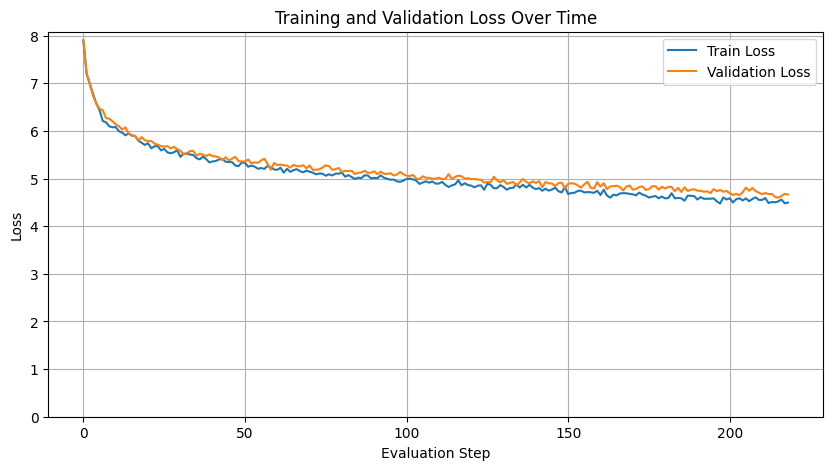

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Evaluation Step")
plt.ylim(0)
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

In [15]:
# generate from the model
input_tokens = tokenizer.encode("I like apple juice - I drink it")
input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=100)

print(tokenizer.decode(output[0].tolist()))

I like apple juice - I drink it some go and I would say, 'You're drinking, so fy to the Gould! For the intuition already featured are now, so often not to stop parkingv's rain, the fact that... is cool; what they transform it... Deach Ermason 'shaul' You do a rewritten',mate [Oh... luck! We're getting in the street before he felt horrible, but I was going in care where the air had to do it. I know
